In [16]:
## Library 호출!

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary # Model 의 구조를 볼수 있는 module

import pytorch_lightning as pl # pytorch lightning !!!

import rdkit
from rdkit import Chem

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn

from sklearn.preprocessing import normalize
from sklearn.preprocessing import StandardScaler

torch.set_default_dtype(torch.float32) # 기본 Data Type 을 float32로 설정 : 소숫점 아래 32자리까지 정확도로 계산하겠다!

from IPython.display import Image # 설명용 Image 삽입 위하여

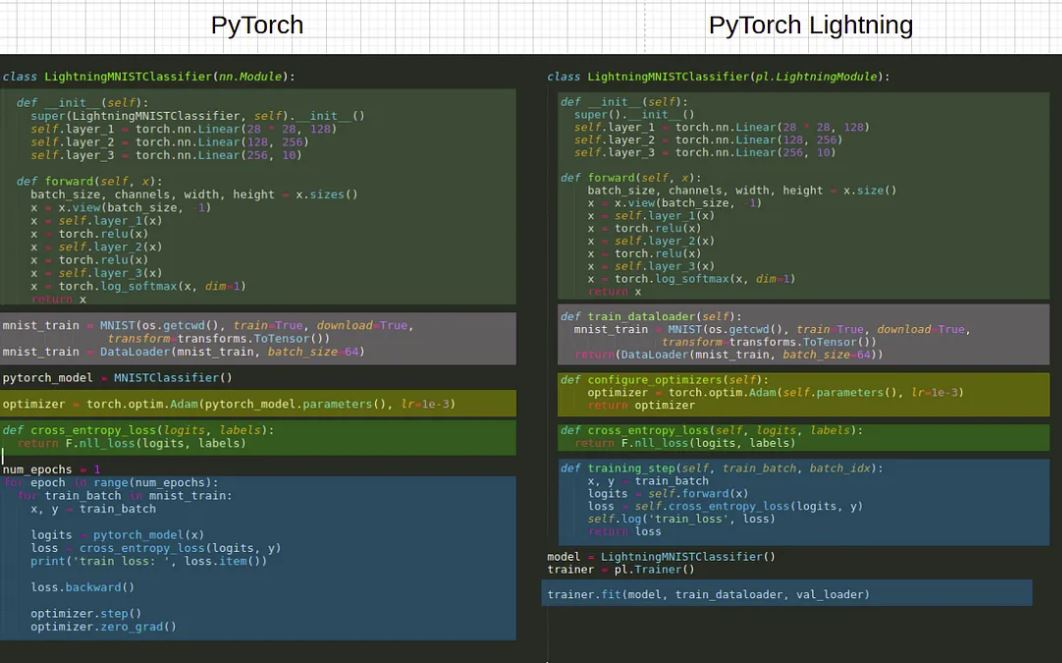

In [17]:
Image('data/18주차_9.JPG')

## PyTorch Lightning : PyTorch 에 대한 'High-level 인터페이스'를 제공하는 오픈소스 Python library
# -> 복잡한 코드를, 간결화 시켜줌!

## trainer Module : pl.Trainer() 로 정의하고
# -> trainer.fit : 마치 sklearn 의 fit 기능처럼 간단함
# -> epoch 돌며 학습진행하는 Part 를 파격적으로 간결화!

## [핵심 구조]
# 1. Model : pl.LightningModule 을 상속받은 NN Class 
# 2. Data : DataLoader module 를 통하여 준비
# 3. trainer.fit 에 : Model(1)과 Data(2) 를 넣고 학습 !

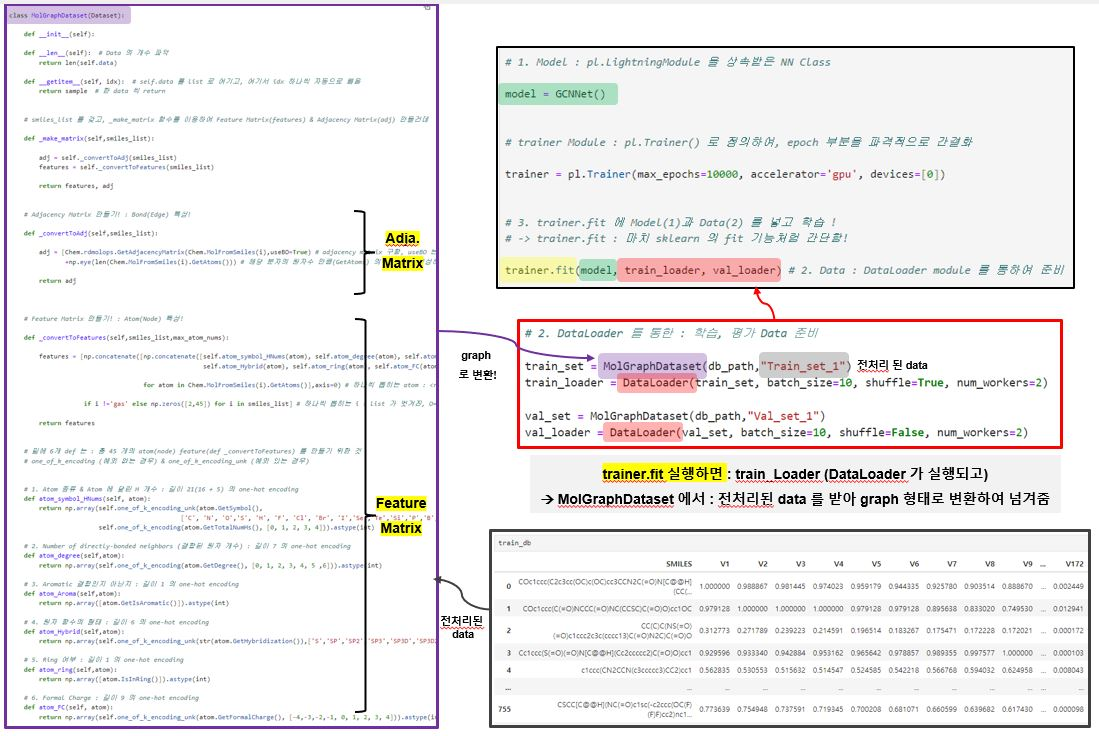

In [18]:
Image('data/18주차_12.JPG')

In [5]:
### 전처리된 Data 를 받아 : DataLoader 에 들어갈 train_set : Graph(Adj + Feature) 만들어주는 Class ###

# 0) train_set = MolGraphDataset(db_path,"Train_set_1") 정의 시 : File 경로(file_path, set_name)를 입력받아서 : __init__ setting

# 1) trainer.fit 실행시 -> Dataloader 동작
# 2) DataLoader ->  MolGraphDataset 하위의, def __getitem__ 동작 : retrun 으로 Graph 변환된 sample(Input(X)-Output(Y) Set) 한쌍 씩 출력함
# 3) 하나씩 return 하는 sample(data)을 : DataLoader에서 10개씩 묶어서(batch_size) : model(GCNNET)의 training_step 에 전달해줌


class MolGraphDataset(Dataset): # torch.utils.data.Dataset 상속받음 : (__init__, __len__, __getitem__) 3개가 Set
    
    
    def __init__(self, file_path, set_name, transform=None): # transform=None : Dataset의 전처리 관련 함수, 적용 안함! (이미 전처리 다 하고 왔으니)   
        
        super().__init__()
        self.data = pd.read_csv(file_path+set_name+'.csv') # file 경로 타고 들어가서, Data 가지고 와서 df로 장전
        

    def __len__(self):  
        return len(self.data) # df(Data 의 개수) 파악    
        

    def __getitem__(self, idx):  # DataLoader 동작 시 :  self.data 에, idx 적용함

        _idx_df = np.array(self.data.iloc[idx]).reshape(1,-1) # df 에서 한줄 빼옴 : Chrom_SMILES(1) + Solv_SMILES(1) + WL(351) : shape(1, 353)

        _smiles = _idx_df[0][0] # Chrom_SMILES : 'O=C(O)c1cc(=O)c2cccc(Cl)c2[nH]1'
        _smiles_sol = _idx_df[0][1] # Solv_SMILES : 'CCO'
        _wl_intensity = [_idx_df[0][2:]] # wl_intensity        

        chrom_A = self._convertToAdj(_smiles) # _smiles 받아서 : adj matrix 만듬
        chrom_H = self._convertToFeatures(_smiles) # _smiles 받아서 : feature matrix 만듬                        
        A_H = np.concatenate([chrom_A, chrom_H],axis=2) # 우선 concatenate (나중에 GCNNet 에서 forward 계산시 다시 뜯음)

        sol_A = self._convertToAdj(_smiles_sol)
        sol_H = self._convertToFeatures(_smiles_sol)                         
        A_H_sol = np.concatenate([sol_A, sol_H],axis=2) # smiles_sol 도 위와 동일하게 진행
        
        # 예) chrom_A(1, 15, 15), chrom_H(1, 15, 45)  ->  concatenate (axis=2)  ->  A_H : 1, 15(원자개수), 60(adj 15 + feature 45)
        
        sample = {'input':[A_H, A_H_sol],'output':np.array(_wl_intensity).astype('float32')}

        # 'input' : A_H & A_H_sol 이 들어있는 list : [(1, 15, 60), (1, 6, 51)]
        # 'output': numpy array : 2차원 (1, 351(_wl_intensity))
        
        return sample  # 한 data 씩 return 해줌! 
        

    
    def _convertToAdj(self, smiles): # Adjacency Matrix 만들기! : Bond(Edge) 특성!
        
        if smiles =='gas':
            adj = np.zeros([2, 2]) # 'gas' 의 경우 : (2,2) zero matrix

        else:
            adj = Chem.rdmolops.GetAdjacencyMatrix(Chem.MolFromSmiles(smiles),useBO=True)
            + np.eye(len(Chem.MolFromSmiles(smiles).GetAtoms())) # 해당 분자의 원자수 만큼(GetAtoms) 의 단위행렬 생성하여 더해 줌 
            # 즉 자기 자신의 연결 정보를 포함하는 adjacency matrix 만듬
                               
        adj = adj.reshape(1, adj.shape[0], adj.shape[1]) # 2차원(15, 15) -> 3차원(1, 15, 15)로 변환
                       
        return adj # 3차원 (1, 15, 15)   

      
    def _convertToFeatures(self, smiles): # Feature Matrix 만들기! : Atom(Node) 특성!
        
        if smiles =='gas':
            features = np.zeros([2,45])  # 'gas' 의 경우 : (2,45) zero matrix

        else:
            features = np.concatenate([np.concatenate([self.atom_symbol(atom), self.atom_HNums(atom), self.atom_degree(atom), self.atom_Aroma(atom), 
                                                       self.atom_Hybrid(atom), self.atom_ring(atom), self.atom_FC(atom)], axis=0).reshape(1,-1)
                                       
                                       for atom in Chem.MolFromSmiles(smiles).GetAtoms()],axis=0) # atom 하나씩 뽑고 (15개 원자로된 분자라고 할때)
        
        # 한 원자에 대한 7개의 feature 구한 다음 : concatenate(axis=0).reshape(1,-1) : (1, 45)
        # 15개 atom 의 feature vector 를 아래로 쭉 쌓음 : concatenate(axis=0)
        # 최종 features 의 shape : 15(원자수) by 45(feature수)

        features = features.reshape(1, features.shape[0], features.shape[1]) # 2차원(15, 45) -> 3차원(1, 15, 45)로 변환                
                                   
        return features  # 3차원 (1, 15, 45) 

        

    # 밑에 7개 def 는 : atom(node) feature 를 만들기 위한 함수
    # one_of_k_encoding (예외 없는 경우) & one_of_k_encoding_unk (예외 있는 경우)
    
    
    # 1. Atom 종류 : 길이 16 의 one-hot vector     
    def atom_symbol(self, atom): 
        return np.array(self.one_of_k_encoding_unk(atom.GetSymbol(), 
                                                   ['C', 'N', 'O','S', 'H', 'F', 'Cl', 'Br', 'I','Se','Te','Si','P','B','Sn','Ge'])).astype(int) # one-hot encoding : astype(int)

    # 2. Atom 에 달린 H 개수 : 길이 5 의 one-hot vector     
    def atom_HNums(self, atom): 
        return np.array(self.one_of_k_encoding(atom.GetTotalNumHs(), [0, 1, 2, 3, 4])).astype(int) # one-hot encoding : astype(int)
        
    # 3. Number of directly-bonded neighbors (결합된 원자 개수) : 길이 7 의 one-hot vector  
    def atom_degree(self,atom):         
        return np.array(self.one_of_k_encoding(atom.GetDegree(), [0, 1, 2, 3, 4, 5 ,6])).astype(int) 
    
    # 4. Aromatic 결합인지 아닌지 : 길이 1 의 one-hot vector
    def atom_Aroma(self,atom):        
        return np.array([atom.GetIsAromatic()]).astype(int)
        
    # 5. 원자 함수의 형태 : 길이 6 의 one-hot vector
    def atom_Hybrid(self,atom):
        return np.array(self.one_of_k_encoding_unk(str(atom.GetHybridization()),['S','SP','SP2','SP3','SP3D','SP3D2'])).astype(int)

    # 6. Ring 여부 : 길이 1 의 one-hot vector
    def atom_ring(self,atom):
        return np.array([atom.IsInRing()]).astype(int)

    # 7. Formal Charge : 길이 9 의 one-hot vector
    def atom_FC(self, atom):
        return np.array(self.one_of_k_encoding_unk(atom.GetFormalCharge(), [-4,-3,-2,-1, 0, 1, 2, 3, 4])).astype(int)
    

    
    def one_of_k_encoding_unk(self, x, allowable_set): # 예외 있는 경우 : (예) def atom_symbol

        # x : atom.GetSymbol() 으로 나온 원자
        # allowable_set : 비교할 list ['C', 'N', 'O','S', 'H', 'F', 'Cl', 'Br', 'I','Se','Te','Si','P','B','Sn','Ge']
        
        if x not in allowable_set:
            x = allowable_set[-1] # x가 allowable set 안에 없는 원소면 : 그냥 list 에 있는 마지막 원소(Ge)로 취급
            
        return list(map(lambda s: x == s, allowable_set)) # (있으면) map + lamda 함수 : x 와 allowable_set 의 원소(s) 와 비교하여, booln list 로 retrun        
     
     # x 가 'C' 이고, allowable_set 이 ['C', 'N', 'O','S', 'H', 'F', 'Cl', 'Br', 'I','Se','Te','Si','P','B','Sn','Ge'] 일 경우
     # -> [True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]    
         
    
    def one_of_k_encoding(self, x, allowable_set): # 예외 없는 경우 : (예) def atom_HNums

        # x : atom.GetTotalNumHs() 로 계산된, H 개수
        # allowable_set : 비교할 list [0, 1, 2, 3, 4]
        
        if x not in allowable_set:
            raise Exception("input {} not in {}:".format(x, allowable_set)) # allowable set list 안에 없는 원소면 : Error message 나오게
            
        return list(map(lambda s: x == s, allowable_set)) # (있으면) map + lamda 함수 : x 와 allowable_set 의 원소(s) 와 비교하여, booln list 로 retrun            
    
    # x 가 '3' 이고, allowable_set 이 [0, 1, 2, 3, 4] 일 경우
    # -> [False, False, False, True, False]

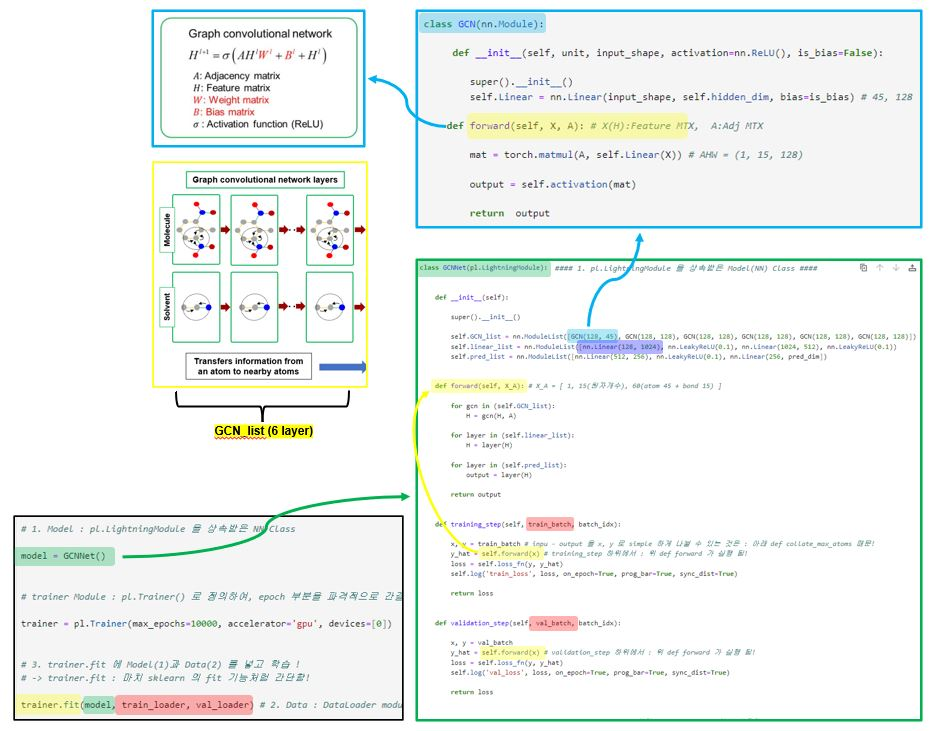

In [6]:
Image('data/18주차_14.JPG')

In [7]:
### GCN Class ###


# 0) model = GCNNet() 정의 시 : GCNNet class 의 __init__ setting 
# -> self.GCN_list = [GCN(45, 128), GCN(128, 128), GCN(128, 128), GCN(128, 128), GCN(128, 128), GCN(128, 128)]

# -> 동시에 GCN class 의 __init__ 도 setting 됨!!


# 1) trainer.fit 실행시 -> model(GCNNet)의 def training_step -> 하위 self.forward() 동작

# -> for gcn in (self.GCN_list):
# ->     H = gcn(A, H) 돌면서 

# -> GCN class 의 forward 동작 됨 !!


class GCN(nn.Module): # [GCN(45, 128), GCN(128, 128), GCN(128, 128), GCN(128, 128), GCN(128, 128), GCN(128, 128)]
    
    def __init__(self, input_dim, unit, activation=nn.ReLU(), is_bias=False): 
        
        super().__init__()

        self.input_dim = input_dim  # 첫번째 layer(45), 나머지 layer(128)
        self.hidden_dim = unit  # 전 layer에서 (128)
        self.activation= activation        
        
        self.Linear = nn.Linear(self.input_dim, self.hidden_dim, bias=is_bias) # (45, 128)
        nn.init.xavier_uniform_(self.Linear.weight) # Weight initialization !(학습 시작시)
        
        if unit != self.input_dim: # 첫 layer(45 != 128)의 경우, self.Linear_dim 이름으로 : 하나 더 장전
            self.Linear_dim = nn.Linear(self.input_dim, self.hidden_dim, bias=is_bias) 
            nn.init.xavier_uniform_(self.Linear_dim.weight)              

        
    def forward(self, A, H): 
               
        mat = torch.matmul(A, self.Linear(H)) # 3차원 matmul : (Batchsize * j * k) matmul (Batchsize * k * l) -> Batchsize * j * l

        # 첫번째 input : A = (10, 15, 15), H = (10, 15, 45) 의 경우
        # -> A(10, 15, 15) matmul self.Linear(45, 128)

        # 1단계 : self.Linear(45, 128) : (H = 10, 15, 45) * (W = 45, 128) -> (H*W = 10, 15, 128) : linear 함수에서 batch 차원은 알아서 맞춰줌
        # 2단계 : A(10, 15, 15) matmul self.Linear(45, 128) : (A = 10, 15, 15) matmul (HW = 10, 15, 128) -> mat(AHW : 10, 15, 128) : bias 는 안씀
        
        
        ## 모든 lyaer 에 Skip Connection 적용해줌 : GCN 통과 값(mat : AHW) + 통과 전 값(H) 합해줌

        if self.hidden_dim != self.input_dim: # 첫번째 Layer (128 != 45) : Linear_dim 으로 새로운 W 도입하여 차원 맞추어 줌
            mat += self.Linear_dim(H) # mat = mat(AHW) + (H*W = 10, 15, 128) -> (AHW : 10, 15, 128) + (HW = 10, 15, 128) -> (AHW + HW = 10, 15, 128)   
        
        else:  # 둘째 Layer 부터는 모두 이 경우 (128 = 128) : Linear_dim 없이 바로 더할 수 있음
            mat += H  # mat = mat(AHW) + (H = 10, 15, 128) -> (AHW : 10, 15, 128) + (H = 10, 15, 128) -> (AHW + H = 10, 15, 128)   

        
        # Activation function 적용 : 3차원 MTX에 ReLu를 씌우면, MTX 안 모든 원소 각각의 값에 ReLu 를 씌워 계산됨 : 결과의 차원에는 변화가 없음        
        
        output = self.activation(mat) # ReLu(AHW + H) -> ReLu(10, 15, 128) -> output(10, 15, 128)
        
        return  output # H^(l+1) 이 되는 것 -> H = gcn(A, H) 의 출력으로 받게 되고 -> 그 다음 layer 의 H 입력으로 다시 들어감!

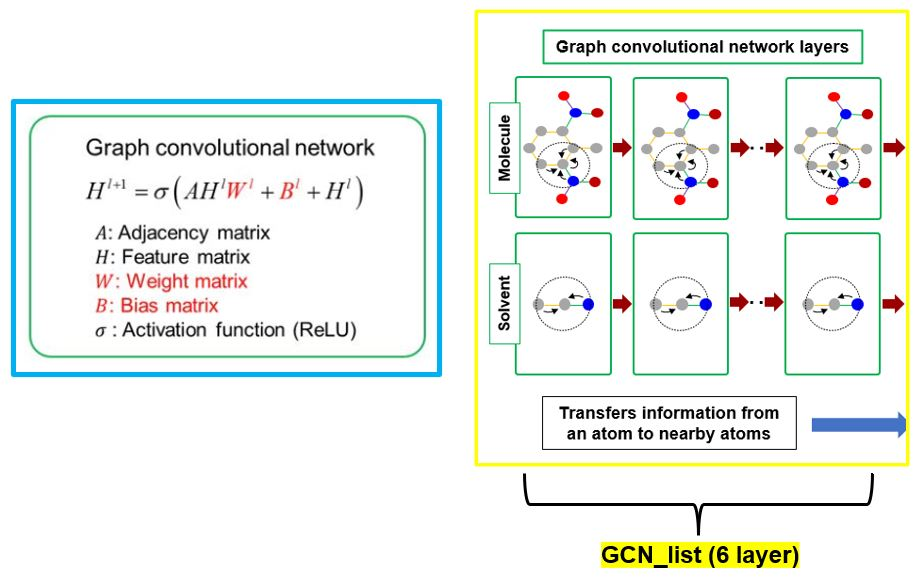

In [8]:
# 아래 Graph convolutional network 식에서 : Bias 는 빠진 것!

Image('data/18주차_15.JPG')

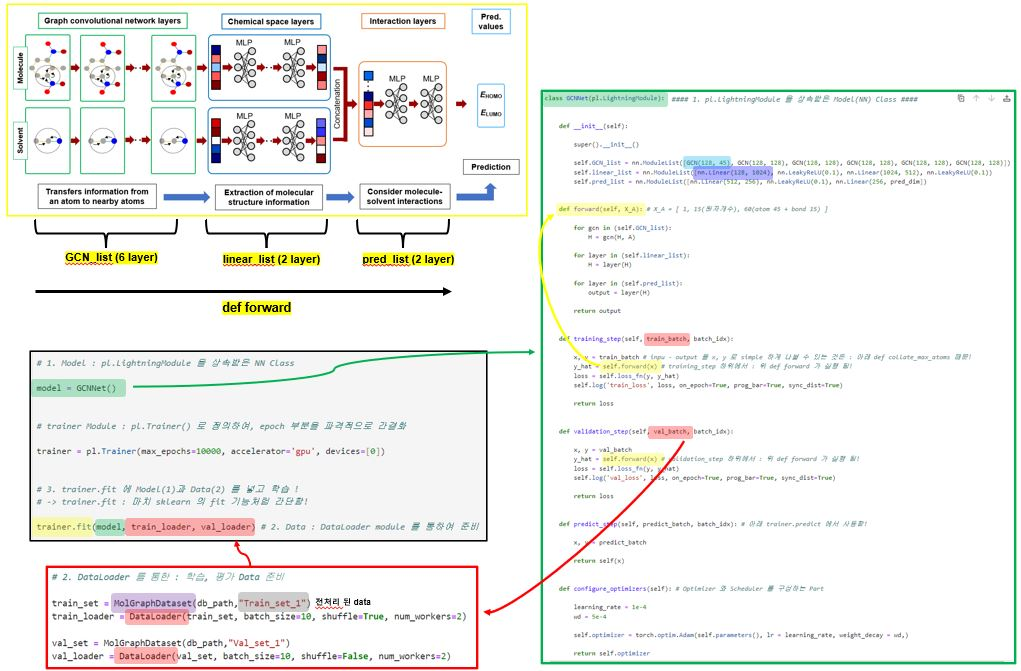

In [9]:
Image('data/18주차_13.JPG')

In [10]:
### GCN Neural Network 를 정의하는 Class ###

# 0) model = GCNNet(db_path, pred_dim=351) 정의 시 :  __init__ (Neural Network 3 덩어리) setting !

# 1) trainer.fit 실행시-> model(GCNNet) 의 def training_step, def validation_step, def configure_optimizer 가 동작함

# 2) def training_step 동작 예시
#  -> train_batch 는 DataLoader(train_loader) 에서 넘겨 줌
#  -> self.forward(x) 동작 : 넘겨받은 train_batch 를, init 에서 setting한 (GCN_list + linear_list + pred_list) 3 덩어리에 순차적으로 통과시킴!


class GCNNet(pl.LightningModule): # pl.LightningModule 상속!
    
    def __init__(self, file_path, pred_dim=351):        
        super().__init__()  
        
        self.file_path = file_path                # db_path = file_path = 'data/abs_spectrum/' : model 관한 정보가 저장될 위치
        self.pred_dim = pred_dim                  # 351
        self.depth = 6                            # GCN 층수
        self.dims = [45,] + [128,] * self.depth   # [45, 128, 128, 128, 128, 128, 128]
        self.loss_fn = self.mae_loss              # 아래에 def mae_loss 로 loss function 정의해 놓음
        activation = nn.LeakyReLU(0.1)          
        is_bias = False

        
        ####### Neural Network 3 덩어리에 걸쳐 쌓음 : [self.GCN_list (6층) -> self.space_list (2층) -> self.interaction_list (2층)] ##########
        

        # Graph convolutional network layers (GCN 6층): [GCN(45, 128), GCN(128, 128), GCN(128, 128), GCN(128, 128), GCN(128, 128), GCN(128, 128)]         
        
        self.GCN_list = nn.ModuleList([GCN(self.dims[i], self.dims[i+1], activation=activation, is_bias=is_bias) 
                                       for i in range(len(self.dims)-1)]) # len(self.dims) = 7,  i = 0,1,2,3,4,5 (6개)       
                
        self.sol_GCN_list = nn.ModuleList([GCN(self.dims[i], self.dims[i+1], activation=activation, is_bias=is_bias) 
                                          for i in range(len(self.dims)-1)]) # solvent CNN Layer 도 동일하게 6층!


        # Chemical space layers (MLP 2개 층) : [nn.Linear(128, 1024), nn.Linear(1024, 512)]

        self.space_list = nn.ModuleList([nn.Linear(self.dims[-1], 1024, bias=True), nn.LeakyReLU(0.1), nn.BatchNorm1d(1024), 
                                          nn.Linear(1024, 512, bias=True), nn.LeakyReLU(0.1), nn.BatchNorm1d(512)])
        
        self.sol_space_list = nn.ModuleList([nn.Linear(self.dims[-1], 1024, bias=True), nn.LeakyReLU(0.1), nn.BatchNorm1d(1024),
                                              nn.Linear(1024, 512, bias=True), nn.LeakyReLU(0.1), nn.BatchNorm1d(512)])        


        # Interaction layers (MLP 2개 층) : [nn.Linear(1024, 512), nn.Linear(512, pred_dim=351)]
       
        self.interaction_list = nn.ModuleList([nn.Linear(1024, 512, bias=True), nn.LeakyReLU(0.1), nn.BatchNorm1d(512),
                                        nn.Dropout(0.5), nn.Linear(512, pred_dim, bias=True)]) # dropout : 마지막 layer Node 의 50%            
        
       
        # 두 덩어리(self.space_list -> self.interaction_list) wiehgt 초기화 (self.GCN_list 는, GCN class 에서 이미 초기화 시켜 줌)
        # 아래에 def _init_weights 로 weight inintialize function 정의해 놓음
        
        self.space_list.apply(self._init_weights)     
        self.sol_space_list.apply(self._init_weights)        
        self.interaction_list.apply(self._init_weights)                  
    

    # trainer.fit 실행 시 : DataLoader 가 data 10개씩(batch size) 넘겨 줌 
    # ->  training_step 에서 train_batch 와 batch_idx 로 짝지어서 넘겨줌 : (10개, 0) -> (10개, 1) -> (10개, 2) -> ...
     
    def training_step(self, train_batch, batch_idx): # train_batch : 'input'[A_H(10, 15, 60), A_H_sol(10, 6, 51)], 'output'(10, 351(_wl_intensity))                
        
        x, y = train_batch # input - output 을 : x, y 로 simple 하게 나눔 (아래 def collate_max_atoms 덕분)
        y_hat = self.forward(x[0], x[1]) # def forward 에 (A_H), (A_H_sol) 나눠서 넘겨줌
        
        loss = self.loss_fn(y, y_hat) # mae_loss 사용 : 한 batch(10개 data)에 대한 loss 값이 나오며 : Back.Propa 진행함 !! (mini batch 경사하강법 적용)
         
        self.log('train_loss', loss, on_epoch=True, prog_bar=True, sync_dist=True) # log 기록 출력 : self.log 는 pl.LightningModule 에 속한 함수
        
        return loss        

    
    def validation_step(self, val_batch, batch_idx): # trainer.fit 시 동일하게 동작 됨, DataLoader 가 (val_batch 와 idx 로 짝지어서) 넘겨 줌
        
        x, y = val_batch
        y_hat = self.forward(x[0], x[1])        
        loss = self.loss_fn(y, y_hat)         
        self.log('val_loss', loss, on_epoch=True, prog_bar=True, sync_dist=True)
        
        return loss
    

    ## (init 에서 setting 해 놓은) Neural Network 3 덩어리를, 차례로 동작시켜 주는 역할! (위 training_step 및 validation_step 에서 동작하여) ##
    
    def forward(self, A_H, A_H_sol): # A_H(10, 15, 60),  A_H_sol(10, 6, 51)        
        
        A = A_H[:, :, :-45] # A = (10, 15(원자개수), 15(adj)) : adjacency matrix             
        H = A_H[:, :, -45:] # H = (10, 15(원자개수), 45(atom)): feature matrix

        A_sol = A_H_sol[:, :, :-45] # solvent 도 동일하게 adjacency : A_sol = (10, 6, 6)
        H_sol = A_H_sol[:, :, -45:] # feature matrix 로 나누어 줌 : H_sol = (10, 6, 45)


        ####### Graph convolutional network layers : for 문 돌면서, 각 GCN layer 6층 통과 ########
        
        for gcn, gcn_sol in zip(self.GCN_list, self.sol_GCN_list): # ModuleList([GCN(45, 128), GCN(128, 128), GCN(128, 128), GCN(128, 128), GCN(128, 128), GCN(128, 128)])            
            
            # GCN(45, 128)의 의미 : Input(45), Output(128) Dimension 이자, Weight 함수의 형태(45 by 128)
            # 밑 gcn 에서 H, A 는 Feature MTX, Adj MTX 
            
            H = gcn(A, H) # GCN class 의 forward 를 동작시킴! : A(Adjacency)는 계속 고정, H(feature)는 Update
            H_sol = gcn_sol(A_sol, H_sol)

        # GCN 6개층 통과 후 : 3차원 H(10, 15, 128) 인데, permutation invariance 를 위하여, 원자 dimenstion(-2) 을 축소 시킴 
        # H(10, 15, 128) -> H(10, 1, 128) -> H(10, 128) : 첫번째 GCN 덩어리 통과후, Vector 가 되는 과정!
            
        H = torch.sum(H, dim=-2) # H(10, 128)
        H_sol = torch.sum(H_sol, dim=-2) # H_sol(10, 128)
        

        ####### Chemical space layers : for 문 돌면서, 각 MLP layer 2층 통과 ########        
            
        for layer, layer_sol in zip(self.space_list, self.sol_space_list): # nn.ModuleList([nn.Linear(128, 1024), nn.Linear(1024, 512)]) 
           
            H = layer(H) # H(10, 512)       
            H_sol = layer_sol(H_sol) # H_sol(10, 512)       
            
        output = torch.cat([H, H_sol], dim=-1) # 두번째 덩어리(MLP)를 통과후, (chr_vector) 와 (solvent_vector) 를 concatenation 시키는 과정! : (10, 1024)


        ####### Interaction layers : for 문 돌면서, 각 MLP layer 2층 통과 ########
                            
        for layer in self.interaction_list: # ModuleList[nn.Linear(1024, 512), nn.Linear(512, pred_dim=351)] 
                     
            output = layer(output) # H & H_sol 합쳤으니, 하나만 통과!
            
        return output        

    
        
    def configure_optimizers(self): # Optimizer 와 Scheduler 구성하는 def
        
        learning_rate = 1e-4
        wd = 5e-4

        lr_patience = 50
        lr_decay = 1-0.015        
        
        # self.parameters() : model 에 있는 모든 학습 가능한 parameter(W,b) 들을 optimizer(optim.Adam)에 전달함.
        # -> 바로 등장할수 있는 이유 : pl.LightningModule 내부함수
        
        # GCNNet class 의 init 단계에서 setting 되는(self.GCN_list, self.linear_list, self.pred_list) 
        # -> 모든 learnable 한 파라미터(W,b)를 가져와서 : optim.Adam 에 넘겨줌! (아래 cell에 그 종류와 개수 확인해봄)
        
        self.optimizer = torch.optim.Adam(self.parameters(), lr = learning_rate, weight_decay = wd) # optimizer setting       
        scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=lr_patience, gamma=lr_decay) # optim 과정에서 learning rate 조절(decay)
        sch_config = {"scheduler" : scheduler, "interval" : "epoch"}
        
        return [self.optimizer], [sch_config]



    # 자체적으로 정의한 loss 와 weight inintialize function
        
    def mae_loss(self, y, y_hat):
        y = y.reshape(-1, self.pred_dim)        
        return torch.mean(torch.absolute((y[~torch.isnan(y)]-y_hat[~torch.isnan(y)])))
    
    
    def _init_weights(self, m): # tensorflow 방식의 weight inintialize 사용!        
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0)

In [15]:
# Build 한 GCNNet Architecture 의 모든 learnable 한 파라미터(W,b) 개수를 확인해보기!

model_test = GCNNet("data/abs_spectrum/")

from prettytable import PrettyTable

def count_parameters(model_test):
    table = PrettyTable(["Modules", "Parameters"])
    total_params = 0
    for name, parameter in model_test.named_parameters():
        if not parameter.requires_grad: continue
        param = parameter.numel()
        table.add_row([name, param])
        total_params+=param
    print(table)
    print(f"Total Trainable Params: {total_params}")
    return total_params

count_parameters(model_test)

+----------------------------------+------------+
|             Modules              | Parameters |
+----------------------------------+------------+
|     GCN_list.0.Linear.weight     |    5760    |
|   GCN_list.0.Linear_dim.weight   |    5760    |
|     GCN_list.1.Linear.weight     |   16384    |
|     GCN_list.2.Linear.weight     |   16384    |
|     GCN_list.3.Linear.weight     |   16384    |
|     GCN_list.4.Linear.weight     |   16384    |
|     GCN_list.5.Linear.weight     |   16384    |
|   sol_GCN_list.0.Linear.weight   |    5760    |
| sol_GCN_list.0.Linear_dim.weight |    5760    |
|   sol_GCN_list.1.Linear.weight   |   16384    |
|   sol_GCN_list.2.Linear.weight   |   16384    |
|   sol_GCN_list.3.Linear.weight   |   16384    |
|   sol_GCN_list.4.Linear.weight   |   16384    |
|   sol_GCN_list.5.Linear.weight   |   16384    |
|       space_list.0.weight        |   131072   |
|        space_list.0.bias         |    1024    |
|       space_list.2.weight        |    1024    |


2212703

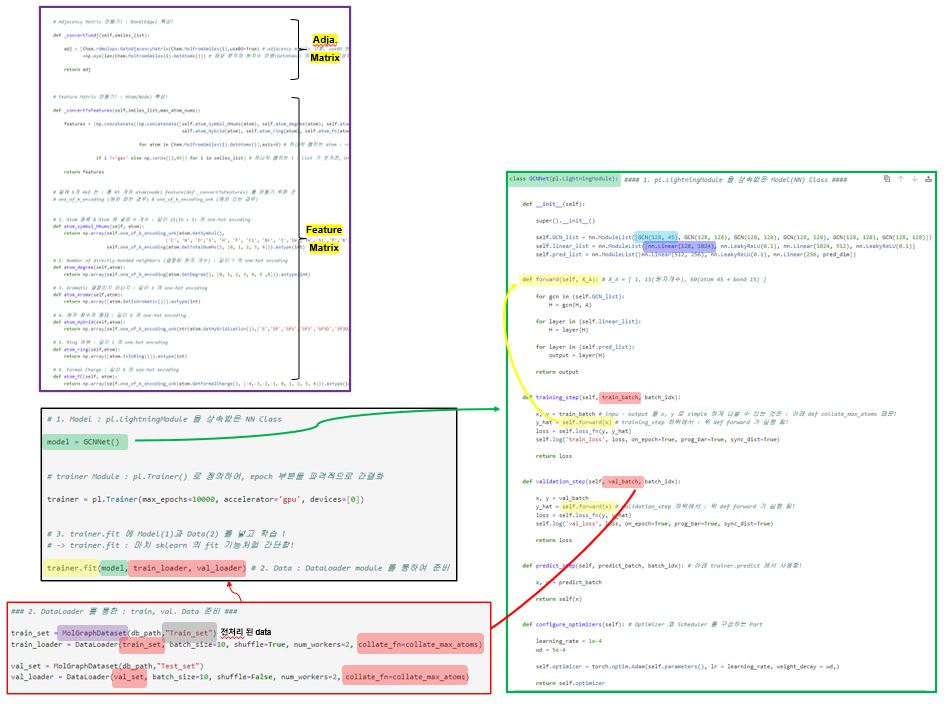

In [12]:
Image('data/18주차_17.JPG')

In [13]:
### DataLoader 에서 train/val_set 을 10개(batch_size)씩 묶기 위하여 : collate function 이용 ###

#  MolGraphDataset 에서, data 하나씩 return 받을때 : data 각각의 dimenstion 이 다름 (분자마다 원자개수 다름)
# -> 1(batch sample수), 15(원자개수), 60(adj 15 + feature 45)
# -> 이 10개 data 의 dimension 을 맞추어(그 중 가장 큰 원자수로) : matrix 연산을 가능하게함



def collate_max_atoms(samples): # sample_i : { 'input' : [(1, 15, 60), (1, 6, 51)], 'output' : (1, 351) }
    

    if len(samples) != 1:
        
        max_numatom = np.max([i["input"][0].shape[1] for i in samples]) # 10개 sample 중, 가장 큰 원자수를 갖는 분자의 : 원자수 찾음!
        max_numatom_sol = np.max([i["input"][1].shape[1] for i in samples])
        
        padding_num = [max_numatom-i["input"][0].shape[1] for i in samples] # 각각 모자란(max-본인)원자수로 이루어진 : 10개 sample list 생성
        padding_num_sol = [max_numatom_sol-i["input"][1].shape[1] for i in samples]
              
        # max 원자 개수로, matrix dimension 을 맞추기 위하여, 모자란 원자 숫자만큼 zero padding 실시! : (0,num,0,num) : 상,하,좌,우       
        padded_samples = [nn.functional.pad(torch.from_numpy(i["input"][0]),(0,num,0,num),value=0) for i,num in zip(samples, padding_num)] # '하'&'우'
        padded_samples_sol = [nn.functional.pad(torch.from_numpy(i["input"][1]),(0,num,0,num),value=0) for i,num in zip(samples, padding_num_sol)]
              
        output = np.concatenate([i["output"] for i in samples],axis=0) # output 은 axis=0(아래)방향으로 쌓음
        
    
    else: # 10개씩 mini_batch 를 잡는데, data 가 마지막 한개가 남는경우        
        
        padded_samples = [torch.from_numpy(i["input"][0]) for i in samples]  
        padded_samples_sol = [torch.from_numpy(i["input"][1]) for i in samples]
        
        output = np.concatenate([i["output"].reshape(1,-1) for i in samples],axis=0)        

    
    return ([torch.cat(padded_samples).type(torch.float32).contiguous(), 
            torch.cat(padded_samples_sol).type(torch.float32).contiguous()], 
            torch.from_numpy(output).type(torch.float32).contiguous()) 

             # contiguous : tensor의 data를, 연속적으로 메모리 상으로 배치시켜 연산속도를 향상시킴
    
             # return 되는 form
             # -> input : 10(batch sample), 35(max원소 수), 80(max원소수 + 45)
             # -> output : 10(batch sample), 351(wavelenth number)   

In [14]:
### 1. Model : pl.LightningModule 을 상속받은 NN Class ###


db_path = 'data/abs_spectrum/' # model 관한 정보가 저장될 위치

model = GCNNet(db_path, pred_dim=351)

In [16]:
### 2. DataLoader 를 통한 : train, val. Data 준비 ###

train_set = MolGraphDataset(db_path,"Train_set")
train_loader = DataLoader(train_set, batch_size=10, shuffle=True, num_workers=2, collate_fn=collate_max_atoms)

val_set = MolGraphDataset(db_path,"Test_set")
val_loader = DataLoader(val_set, batch_size=10, shuffle=False, num_workers=2, collate_fn=collate_max_atoms)

# DataLoader 의 특징 : Input(x)-Output(y) 하나의 Set 를 받는다!
# -> MolGraphDataset 의 return : { 'input' : [(1, 15, 60), (1, 6, 51)], 'output' : (1, 351) })

FileNotFoundError: [Errno 2] No such file or directory: 'data/abs_spectrum/Train_set.csv'

In [ ]:
model_name = 'lr_4_mae_d4c'
model_path = 'model/' + model_name

class LossPlotCallback(pl.Callback):
    
    def __init__(self, plot_interval=10):
        
        self.train_losses = []
        self.val_losses = []
        self.plot_interval = plot_interval
        self.epochs = []  # 각 에포크마다의 에포크 번호를 저장할 리스트

    def on_train_epoch_end(self, trainer, pl_module):
        
        current_epoch = trainer.current_epoch
        # 매 plot_interval번째 에포크에서 그래프를 그립니다.
        
        if current_epoch % self.plot_interval == 0:
            
            # 학습 및 검증 손실에 액세스
            train_loss = trainer.callback_metrics['train_loss']
            val_loss = trainer.callback_metrics['val_loss']

            # 손실을 리스트에 저장
            self.train_losses.append(train_loss.item())
            self.val_losses.append(val_loss.item())
            self.epochs.append(current_epoch)  # 에포크 번호를 저장
            
            if current_epoch % 10 == 0:
                
                # 손실을 그래프로 그립니다
                plt.plot(self.epochs, self.train_losses, c='black', label='Train Loss')
                plt.plot(self.epochs, self.val_losses, c='red', label='Validation Loss')
                plt.ylim([0.01, 3e+4])
                
                # x 및 y 축에 레이블 추가
                plt.xlabel('Epoch')
                plt.ylabel('Loss')
                
                # 범례 추가
                plt.legend()             


checkpoint_callback = pl.callbacks.ModelCheckpoint(dirpath=db_path+model_path, 
                                                   filename='{epoch}-{val_loss:.4f}',
                                                   every_n_epochs=100,
                                                   save_top_k=1,
                                                   monitor='val_loss',
                                                   mode='min',
                                                   save_last=True)
loss_plot_callback = LossPlotCallback()

In [ ]:
# trainer Module : pl.Trainer() 로 정의하여, epoch 돌며 학습진행하는 Part 를 파격적으로 간결화!

trainer = pl.Trainer(max_epochs=50, accelerator='gpu', devices=[0],
                     callbacks=[checkpoint_callback, loss_plot_callback]) 


# 3. trainer.fit 에 Model(1)과 Data(2) 를 넣고 학습 !

# (1). model(GCNNet class 의 init 을 setting 해준) 의  
# -> 하위 def : def training_step, def validation_step, def configure_optimizers 가 동작 하는데
# -> 아래 2번(train_loader, val_loader)을 data 로 받음!

# (2). train_loader, val_loader 
# -> train_set, val_set : (data file 경로를 받아서) MolGraphDataset class 의 init setting 후
# -> DataLoader 에서 MolGraphDataset class 의 하위 def __getitem__ 동작 : Feature & Adjacency MTX 변환하여
# -> Input(x)-Output(y) 하나의 Set 로 : (10 batch 묶어서) 위 1번으로 던짐(return)!

trainer.fit(model, train_loader, val_loader) 

In [ ]:
## 분자 찾고 비교하기 위하여, shuffle=False 로 다시 설정함

db_path = 'data/abs_spectrum/'

train_set = MolGraphDataset(db_path,"Train_set")
train_loader = DataLoader(train_set, batch_size=10, shuffle=False, num_workers=2, collate_fn=collate_max_atoms)

val_set = MolGraphDataset(db_path,"Val_set")
val_loader = DataLoader(val_set, batch_size=10, shuffle=False, num_workers=2, collate_fn=collate_max_atoms)

In [ ]:
# load_from_checkpoint : 학습된 weight 를 GCNNet Model 에 적용! (해당경로에 있는 check point 의 정보를 토대로)


# db_path = 'data/abs_spectrum/'
# model_path = 'model/' + model_name
# model_name = 'test1'

model_trained = GCNNet.load_from_checkpoint(checkpoint_path=db_path + model_path + '/epoch=99-val_loss=20527.0098.ckpt',
    file_path=db_path + model_path + '/epoch=99-val_loss=20527.0098.ckpt')

In [ ]:
## model_trained 이용하여 Predict !!!

train_pred = list() # 예측
train_y = list() # 정답

val_pred = list() # 예측
val_y = list() # 정답

model_trained = model_trained.cuda(1)
model_trained.eval() # dropout,batchnorm,.. 등등 학습에 사용하는 Option 들 비 활성화 됨!


with torch.no_grad(): # 아래 계산시 B.P.을 통한 weight update 하지 않음!
    
    for x, y in train_loader:
        
        y_hat = model_trained(x[0].cuda(1), x[1].cuda(1))
        train_pred.append(y_hat)                
        train_y.append(y)        
        
    for x, y in val_loader:
        
        y_hat = model_trained(x[0].cuda(1), x[1].cuda(1))
        val_pred.append(y_hat)          
        val_y.append(y)


train_pred = torch.cat(train_pred,axis=0).cpu().numpy()
train_y = torch.cat(train_y,axis=0).cpu().numpy()

val_pred = torch.cat(val_pred,axis=0).cpu().numpy()
val_y = torch.cat(val_y,axis=0).cpu().numpy()

In [ ]:
### Evaluation : MAE(Mean Absolute Error) ###

train_mae = list()
val_mae = list()

def mae(y,pred):        
    non_nan_indices = ~np.isnan(y) & ~np.isnan(pred) # 값 있는 합집합 영역 : boolean      
    return np.mean(np.abs(y[non_nan_indices] - pred[non_nan_indices]))

for i in range(train_y.shape[0]): # (805, 351) 에서 train data 수[0]
    train_mae.append(mae(train_y[i],train_pred[i]))    
  
for i in range(val_y.shape[0]):
    val_mae.append(mae(val_y[i],val_pred[i]))

print("Train의 Mean MAE 값 :", np.mean(train_mae))
print("Test의 Mean MAE 값 :", np.mean(val_mae))

In [ ]:
# Train 대표 결과 값 찾아봄 (6개)

train_sorted_elements = sorted(list(enumerate(train_mae)), key=lambda x: x[1])
train_selec_indices = [i * (len(train_mae) // 5) for i in range(1, 5)]

train_selected_values = [train_sorted_elements[i] for i in train_selec_indices]
train_selected_values

# 전체 train set 의 MAE 기준 나래비 세우고, 5 등분 함

In [ ]:
## Train data Set : Spectrum 그려서 비교해보기!

import matplotlib.pyplot as plt

x = np.linspace(200, 900, 351)

i = 173

plt.scatter(x,train_y[i],c='b',s=1)
plt.scatter(x,train_pred[i],c='r',s=1)


train_path = 'data/abs_spectrum/Train_set.csv'
view_train_df = pd.read_csv(train_path)

print(view_train_df.loc[i, 'Chrom_SMILES'])
print(view_train_df.loc[i, 'Solv_SMILES'])
print(train_mae[i])

Chem.MolFromSmiles(view_train_df.loc[i, 'Chrom_SMILES'])